# 06 — Verify CLIP type tags

Phase 1 of the multi-image fine-tuning plan. Confirm that Leon's scrape-time CLIP
zero-shot classifier did a good enough job tagging photos as `garment` vs `label`
before we train on those tags.

**Decision gate (plan §1.3):**

| Result on the OCR-density check | Action |
|---|---|
| ≥80% of `label` photos have ≥5 detected words | Use tags as-is, proceed to Phase 2 |
| 60–80% | Use tags but add OCR-density override at build_manifest time |
| <60% | Re-classify all photos with `scripts/reclassify_clip.py` |

Run on the smallest scrape first (`clothing_2026-04-26_2110`, ~1700 photos)
downloaded locally via rclone, before pulling the full zip to the pod.

## 0. Config — point this at the local sample

In [1]:
from pathlib import Path
import json, random, shutil
import pandas as pd

REPO_ROOT = Path('/Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/04_T4/04_Advanced Machine Learning/Advanced_ML')
SCRAPE_DIR = REPO_ROOT / 'data' / 'data_leon' / 'raw' / 'clothing_2026-04-26_2110'
SAMPLE_DIR = Path('./samples')  # eyeball-export target
N_PER_CLASS_OCR = 200            # OCR-density sample size per tag
N_PER_CLASS_EXPORT = 50          # manual eyeball-export sample size per tag
MIN_LABEL_WORDS = 5              # OCR words threshold for 'looks like a label'
MAX_GARMENT_WORDS = 3            # OCR words threshold for 'looks like a garment'
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
assert SCRAPE_DIR.exists(), f'scrape dir not found: {SCRAPE_DIR}'
items_jsonl = SCRAPE_DIR / 'items.jsonl'
assert items_jsonl.exists(), f'items.jsonl missing in {SCRAPE_DIR}'
print(f'scrape: {SCRAPE_DIR.name}')

scrape: clothing_2026-04-26_2110


## 1. Load items.jsonl and group photos by CLIP tag

Defensive about Leon's exact format — handles both:
* one row per (listing, photo) with `image` + `type` fields
* one row per listing with an `images` list of `{path, type}`

In [2]:
GARMENT_ALIASES = {'garment', 'clothing', 'wear', 'apparel'}
LABEL_ALIASES   = {'label', 'tag', 'care_label', 'care-label', 'carelabel'}
# 'other' (junk shots — not a garment, not a label) gets passed through and ignored downstream.

def normalize_tag(t):
    if t is None: return None
    s = str(t).strip().lower()
    if s in GARMENT_ALIASES: return 'garment'
    if s in LABEL_ALIASES:   return 'label'
    return s

def iter_photos(scrape_dir):
    with open(scrape_dir / 'items.jsonl') as f:
        for line in f:
            obj = json.loads(line)
            listing_id = obj.get('id') or obj.get('listing_id')
            # Leon's scraper writes `all_photos`; older guesses used `images`.
            imgs = obj.get('all_photos') or obj.get('images')
            if isinstance(imgs, list) and imgs:
                for img in imgs:
                    if isinstance(img, str):
                        yield listing_id, scrape_dir / img, None
                    elif isinstance(img, dict):
                        path = img.get('path') or img.get('image') or img.get('file')
                        if path:
                            yield listing_id, scrape_dir / path, normalize_tag(img.get('type') or img.get('clip_type') or img.get('tag'))
            else:
                p = obj.get('image') or obj.get('path')
                if p:
                    yield listing_id, scrape_dir / p, normalize_tag(obj.get('type') or obj.get('clip_type') or obj.get('tag'))

photos = pd.DataFrame(
    [{'listing_id': lid, 'path': str(p), 'tag': t} for lid, p, t in iter_photos(SCRAPE_DIR)]
)
print(f'total photos: {len(photos):,}')
print(photos['tag'].value_counts(dropna=False))

total photos: 2,917
tag
garment    1788
label       739
other       390
Name: count, dtype: int64


## 2. OCR-density check — programmatic verification

Sample 200 of each class, run pytesseract, count words ≥3 chars. Real labels
have 5–30 detected words; real garment shots have <3.

In [3]:
import pytesseract
from PIL import Image
from tqdm.auto import tqdm

# Surface a missing tesseract binary up-front instead of silently 0%-ing the run.
# Install with `brew install tesseract` on macOS.
try:
    pytesseract.get_tesseract_version()
except pytesseract.TesseractNotFoundError as e:
    raise RuntimeError(
        "tesseract binary not found on PATH. Install it (macOS: `brew install tesseract`) "
        "and restart the kernel."
    ) from e

# Verify the photos are actually present on disk before OCR-ing 400 of them.
sample_for_check = photos['path'].head(20).tolist()
missing = [p for p in sample_for_check if not Path(p).exists()]
if missing:
    raise RuntimeError(
        f"{len(missing)}/{len(sample_for_check)} sampled photo paths don't exist on disk, e.g.\n  "
        f"{missing[0]}\n"
        f"The Drive download likely skipped the images/ subfolder — re-download it before continuing."
    )

def ocr_word_count(path, min_len=3):
    txt = pytesseract.image_to_string(Image.open(path))
    return len([w for w in txt.split() if len(w) > min_len])

def sample_paths(df, tag, n):
    pool = df[df['tag'] == tag]
    if len(pool) == 0:
        return []
    return pool.sample(n=min(n, len(pool)), random_state=RANDOM_SEED)['path'].tolist()

label_paths   = sample_paths(photos, 'label',   N_PER_CLASS_OCR)
garment_paths = sample_paths(photos, 'garment', N_PER_CLASS_OCR)
print(f'sampled {len(label_paths)} labels + {len(garment_paths)} garments')

/opt/miniconda3/envs/AD_ML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sampled 200 labels + 200 garments


In [4]:
label_counts   = [ocr_word_count(p) for p in tqdm(label_paths,   desc='OCR labels')]
garment_counts = [ocr_word_count(p) for p in tqdm(garment_paths, desc='OCR garments')]

label_ok   = sum(1 for c in label_counts   if c is not None and c >= MIN_LABEL_WORDS) / max(len(label_counts), 1)
garment_ok = sum(1 for c in garment_counts if c is not None and c <= MAX_GARMENT_WORDS) / max(len(garment_counts), 1)

print()
print(f'"label"   tagged photos: {label_ok:.1%} have >= {MIN_LABEL_WORDS} OCR words (looks like a real label)')
print(f'"garment" tagged photos: {garment_ok:.1%} have <= {MAX_GARMENT_WORDS} OCR words (looks like a real garment shot)')

OCR garments: 100%|██████████| 200/200 [00:21<00:00,  9.11it/s]


"label"   tagged photos: 12.0% have >= 5 OCR words (looks like a real label)
"garment" tagged photos: 98.5% have <= 3 OCR words (looks like a real garment shot)


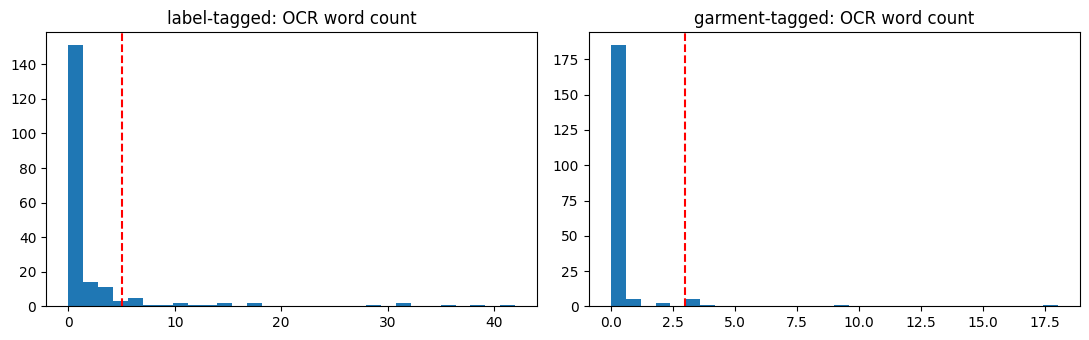

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([c for c in label_counts if c is not None],   bins=30); axes[0].set_title('label-tagged: OCR word count')
axes[0].axvline(MIN_LABEL_WORDS, color='red', ls='--')
axes[1].hist([c for c in garment_counts if c is not None], bins=30); axes[1].set_title('garment-tagged: OCR word count')
axes[1].axvline(MAX_GARMENT_WORDS, color='red', ls='--')
plt.tight_layout(); plt.show()

## 3. Decision gate

Read the percentages above and pick the next action per the table at the top.
Save the numbers somewhere durable — they justify the Phase 2 decision.

In [6]:
summary = {
    'scrape': SCRAPE_DIR.name,
    'n_label_ocr':   len(label_counts),
    'n_garment_ocr': len(garment_counts),
    'label_ok_rate':   label_ok,
    'garment_ok_rate': garment_ok,
    'min_label_words':   MIN_LABEL_WORDS,
    'max_garment_words': MAX_GARMENT_WORDS,
}
out_path = Path('./clip_tag_verification_summary.json')
out_path.write_text(json.dumps(summary, indent=2))
print(f'wrote {out_path}')
summary

wrote clip_tag_verification_summary.json


{'scrape': 'clothing_2026-04-26_2110',
 'n_label_ocr': 200,
 'n_garment_ocr': 200,
 'label_ok_rate': 0.12,
 'garment_ok_rate': 0.985,
 'min_label_words': 5,
 'max_garment_words': 3}

## 4. Manual sample export — 50 of each class for eyeball verification

In [7]:
for tag in ['label', 'garment']:
    target_dir = SAMPLE_DIR / tag
    target_dir.mkdir(parents=True, exist_ok=True)
    for src in sample_paths(photos, tag, N_PER_CLASS_EXPORT):
        dst = target_dir / Path(src).name
        if not dst.exists():
            shutil.copy(src, dst)
    print(f'exported to {target_dir}')
print('open these folders, scroll through, sanity-check the tags match the photos')

exported to samples/label
exported to samples/garment
open these folders, scroll through, sanity-check the tags match the photos
